In [1]:

from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")
from src.layers.transformer.ATAT import LightCurveTransformer, TabularTransformer

from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import classification_report

from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes
from src.exploringtools.InitDataloader import InitDataLoader
from src.layers.classifiers.MultimodalClassifier import MultimodalClassifier
from src.layers.transformer.ATAT import LightCurveTransformer
from src.exploringtools.InitClassifier import InitClassifier, ztf_order_classes

In [12]:
DATASET  ='test'
DEVICE = 'cuda:0'
PATH_1 ='/home/magdalena/rpos/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/PRETRAIN/LC/class_anomaly_0/'
PATH_2 = '/home/magdalena/rpos/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/PRETRAIN/LC/class_baseline_0_sampler_seqnorm/'

from src.utils.data.AlerceDictionaries import ELASTICC_TAXONOMY, ZTF_TAXONOMY

FP_DATASET = "/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12/dataset.h5"
#FP_DATASET = "/home/mdelafuente/ORIGINAL/elasticc_dataset_update.h5"
FP_DATASET ='/home/magdalena/Desktop/sambashare/H5_files/BY_PARTITION/200_FF.h5'

Using checkpoint 1584.ckpt
Using checkpoint 1584.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


  0%|          | 0/477 [00:00<?, ?it/s]

100%|██████████| 477/477 [00:07<00:00, 60.91it/s]


                precision    recall  f1-score   support

           AGN     0.5825    0.2986    0.3948       556
           QSO     0.6108    0.8316    0.7043       570
            EA     0.7664    0.8175    0.7912       570
           YSO     0.5791    0.6016    0.5901       487
          SNIa     0.8317    0.8866    0.8583       485
       CV/Nova     0.7617    0.7094    0.7346       320
          RRLc     0.6289    0.7388    0.6794       578
         RSCVn     0.5728    0.3896    0.4638       444
        Blazar     0.4245    0.5519    0.4799       270
          SNII     0.7890    0.6825    0.7319       274
         EB/EW     0.7459    0.7059    0.7253       578
           LPV     0.8515    0.9293    0.8887       580
           CEP     0.6141    0.5848    0.5991       566
         RRLab     0.6645    0.8643    0.7513       582
Periodic-Other     0.4345    0.3042    0.3578       240
          DSCT     0.5281    0.3092    0.3900       304
         SNIbc     0.3763    0.4070    0.3911  

<Axes: title={'center': 'Lightcurve Classification | Dataset: test | macro f1: 0.5209'}, xlabel='Predicted label', ylabel='True label'>

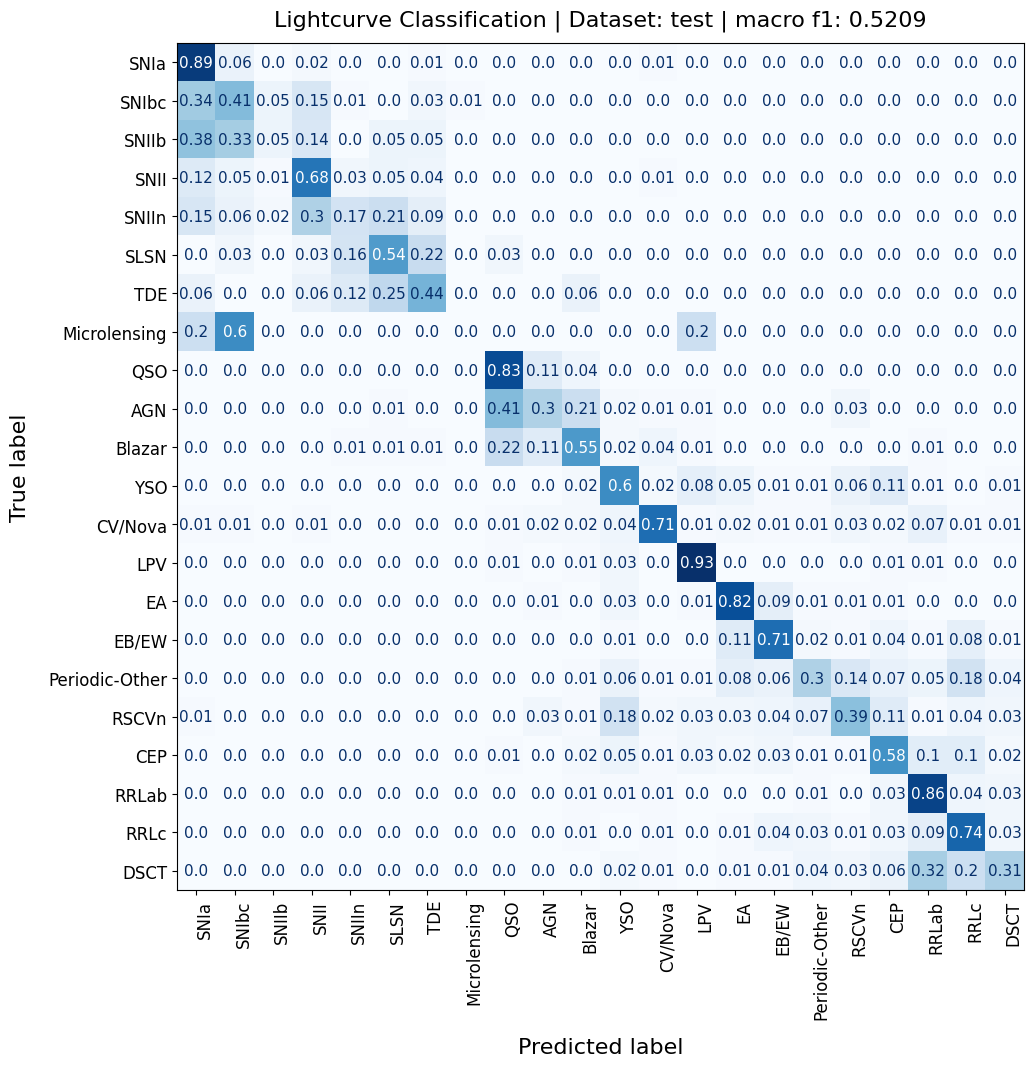

In [18]:
test = InitClassifier(path_to_config_yaml=PATH_1,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False


dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_1 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))

#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'Lightcurve Classification | Dataset', order_classes=ztf_order_classes)


Using checkpoint 2064.ckpt
Using checkpoint 2064.ckpt
     - Loaded backbone weights
     - Loaded classifier weights
device set to cuda:0


  0%|          | 0/477 [00:00<?, ?it/s]

100%|██████████| 477/477 [00:07<00:00, 67.59it/s] 


                precision    recall  f1-score   support

           AGN     0.5652    0.3741    0.4502       556
           QSO     0.6559    0.7491    0.6994       570
            EA     0.7932    0.7737    0.7833       570
           YSO     0.5471    0.5606    0.5538       487
          SNIa     0.8539    0.7835    0.8172       485
       CV/Nova     0.7191    0.6719    0.6947       320
          RRLc     0.6850    0.6696    0.6772       578
         RSCVn     0.4968    0.5248    0.5104       444
        Blazar     0.4543    0.5333    0.4906       270
          SNII     0.7957    0.6825    0.7348       274
         EB/EW     0.7155    0.7093    0.7124       578
           LPV     0.9251    0.8517    0.8869       580
           CEP     0.6543    0.5618    0.6046       566
         RRLab     0.7660    0.7199    0.7422       582
Periodic-Other     0.3409    0.4375    0.3832       240
          DSCT     0.4066    0.6086    0.4875       304
         SNIbc     0.3276    0.4419    0.3762  

<Axes: title={'center': 'Lightcurve Classification | Dataset: test | macro f1: 0.5394'}, xlabel='Predicted label', ylabel='True label'>

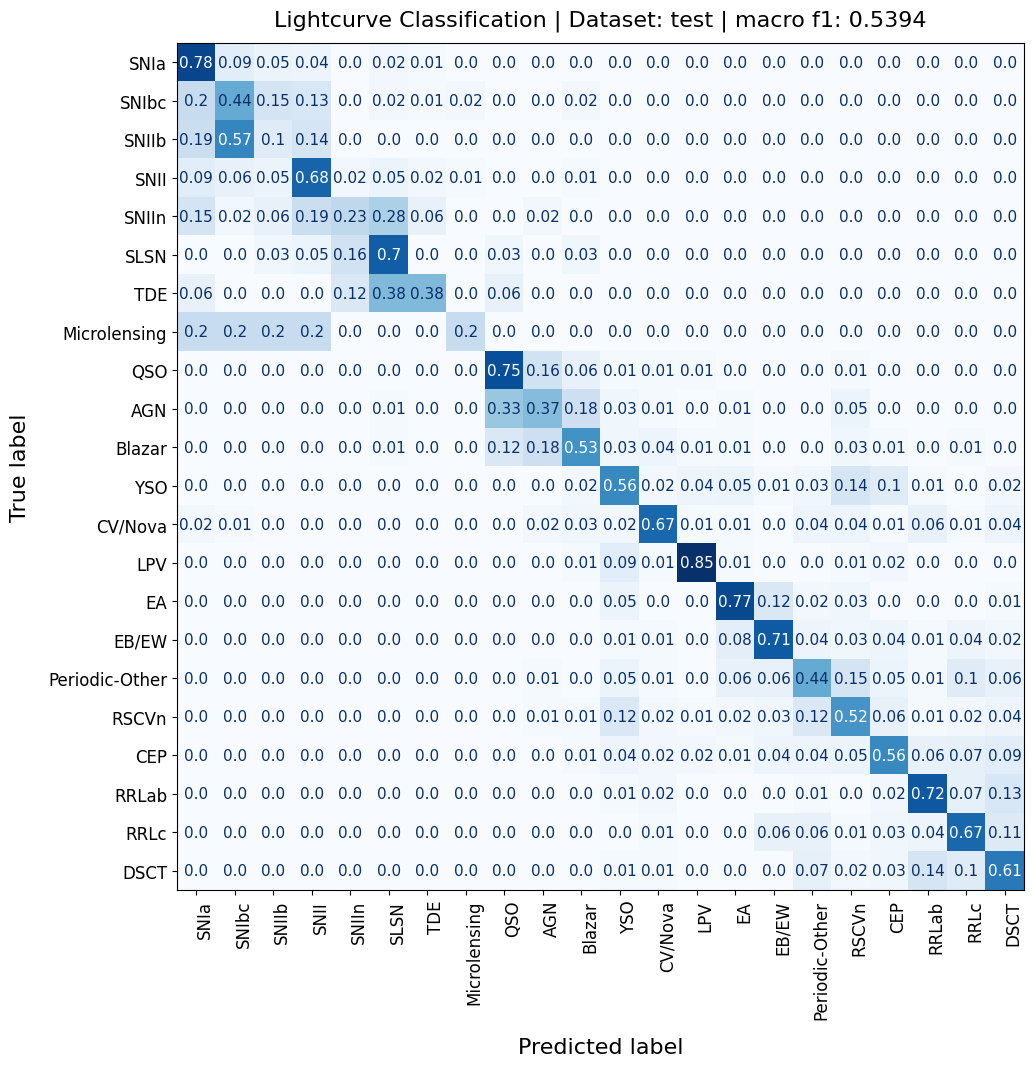

In [72]:
test = InitClassifier(path_to_config_yaml=PATH_2,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False


dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
val_preds, val_true =test.predict(dl.test_dataset, DEVICE) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)
report_2 = classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds, axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))

#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'Lightcurve Classification | Dataset', order_classes=ztf_order_classes)


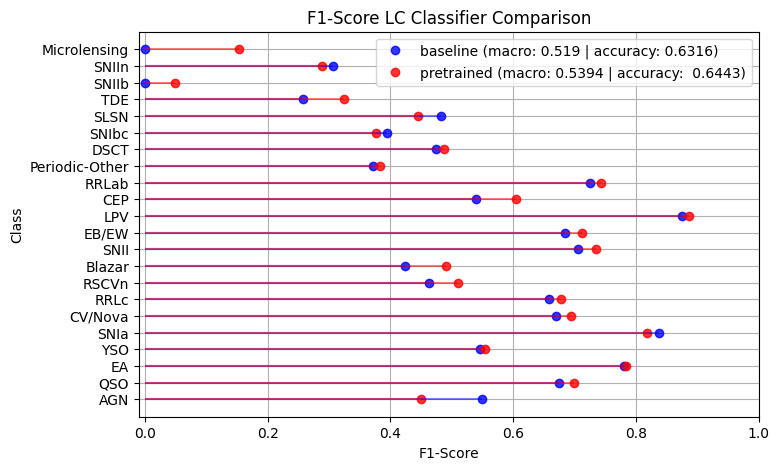

baseline f1 mean:
trans 0.3731186054916797
stoch 0.5727742334806741
per 0.6188424247548138
pretrained f1 mean:
trans 0.3858949437961909
stoch 0.575256599690172
per 0.6309601080605063


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in d1.items():
       # print(key,value)
        if key in ZTF_TAXONOMY().keys():

            f1_baseline.append(value['f1-score'])

    df_1 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_baseline })
    ordered_df_1 = df_1 #.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)

    for key,value in d2.items():
        if key in (ZTF_TAXONOMY().keys()):
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':ZTF_TAXONOMY().keys(), 'values':f1_finetune})
    ordered_df_2 = df_2 #.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])

    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)

    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(-0.01,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )

    plt.legend([f'baseline (macro: {np.round(d1['macro avg']['f1-score'],4)} | accuracy: {np.round(d1['accuracy'],4)})',
                f'pretrained (macro: {np.round(d2['macro avg']['f1-score'],4)} | accuracy:  {np.round(d2['accuracy'],4)})'])
    # Show the plot
    plt.show()
compare_models(report_1,report_2)

transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}

periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}
import numpy as np
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in report_1.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():

        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('baseline f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))
for class_key, value in report_2.items():
    #print(class_key)
    if class_key in ZTF_TAXONOMY().keys():

        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('pretrained f1 mean:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

In [64]:
#
# t_ =

import pandas as pd

df = pd.DataFrame({'true':val_true, 'pred':np.argmax(val_preds, axis = -1)})

transient_dict = ZTF_TAXONOMY.transient.group
transients = df.query('true in {}'.format(list(transient_dict.values())))
print(classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=False))

##
stochastic_dict = ZTF_TAXONOMY.stochastic.group
stochastics = df.query('true in {}'.format(list(stochastic_dict.values())))
print(classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=False))
####
periodic_dict = ZTF_TAXONOMY.periodic.group
periodics = df.query('true in {}'.format(list(periodic_dict.values())))
print(classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=False))


sum([classification_report(transients['true'], transients['pred'],target_names= list(ZTF_TAXONOMY.transient.group.keys()),labels = list(ZTF_TAXONOMY.transient.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(stochastics['true'], stochastics['pred'],target_names= list(ZTF_TAXONOMY.stochastic.group.keys()),labels = list(ZTF_TAXONOMY.stochastic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score'],
classification_report(periodics['true'], periodics['pred'],target_names= list(ZTF_TAXONOMY.periodic.group.keys()),labels = list(ZTF_TAXONOMY.periodic.group.values()),digits = 4, output_dict=True)['macro avg']['f1-score']])/3

              precision    recall  f1-score   support

        SNIa     0.8260    0.5773    0.6796       485
        SNII     0.7436    0.4234    0.5395       274
       SNIbc     0.2138    0.3605    0.2684        86
        SLSN     0.4211    0.4324    0.4267        37
         TDE     0.1127    0.5000    0.1839        16
       SNIIb     0.0488    0.2857    0.0833        21
       SNIIn     0.2885    0.2830    0.2857        53
Microlensing     0.0000    0.0000    0.0000         5

   micro avg     0.4979    0.4831    0.4904       977
   macro avg     0.3318    0.3578    0.3084       977
weighted avg     0.6719    0.4831    0.5488       977

              precision    recall  f1-score   support

         AGN     0.5212    0.3759    0.4368       556
         QSO     0.6064    0.6649    0.6343       570
         YSO     0.8688    0.5031    0.6372       487
     CV/Nova     0.8756    0.5938    0.7076       320
      Blazar     0.4060    0.4481    0.4261       270

   micro avg     0.6275

0.49155536025772983

In [65]:
test = InitClassifier(path_to_config_yaml=PATH_2,
                    model= LightCurveTransformer,
                    classifier = MultimodalClassifier,
                    use_lc = True,
                    arg_key='lc')

backbone_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'classifier'],rename_keys = ('model.',''), checkpoint_name='classifier_ckpt')
classifier_od = test.create_ordered_dict(remove_if_in_key_list=['projection', 'model',],rename_keys = ('classifier.',''), checkpoint_name='classifier_ckpt')
test.load_backbone_weights(backbone_od)

test.load_classifier_weights(classifier_od)
test.args.datamodule.val_use_sampler = False

dl = InitDataLoader(update_dataset_path=FP_DATASET,update_batch_size=16,datamodule_args=test.args.datamodule)
dl.init_test_dataset()
import numpy as np
from sklearn.metrics import classification_report
val_preds, val_true =test.predict_by_time(dl.test_dataset, DEVICE,eval_times = [t_]) if DATASET == 'test' else test.predict(dl.validation_dataset, DEVICE)


Using checkpoint 480.ckpt
Using checkpoint 480.ckpt
     - Loaded backbone weights
     - Loaded classifier weights


NameError: name 't_' is not defined

In [ ]:
ffff

In [ ]:
import torch

# Example tensor
bsz, seqlen, channels = 2, 5, 3
x = torch.randn(bsz, seqlen, channels)

dt = 0.2

# find min per sample (over seqlen & channels)
min_vals, _ = x.view(bsz, -1).min(dim=1)   # shape [bsz]

# reshape for broadcasting: [bsz, 1, 1]
min_vals = min_vals.view(bsz, 1, 1)

# compute mask
mask = x < (min_vals + dt)

print("x shape:", x)
print("mask shape:", mask)


x shape: tensor([[[ 3.0852e-01, -4.1230e-01, -3.1842e-01],
         [ 8.0920e-04,  4.6384e-02, -5.4418e-01],
         [-7.0441e-01, -7.7820e-01, -9.5111e-01],
         [-5.2094e-01,  7.6540e-02,  1.5215e-01],
         [ 2.2895e+00,  1.1036e+00,  1.2113e+00]],

        [[-4.2369e-02, -7.3361e-02,  6.4931e-01],
         [-3.5681e-01, -2.1312e+00, -2.7035e+00],
         [ 1.0417e-01, -1.2709e+00, -1.2558e+00],
         [-6.2700e-01, -2.2226e+00, -9.7979e-01],
         [ 4.0984e-01, -1.1913e+00, -2.1165e-01]]])
mask shape: tensor([[[False, False, False],
         [False, False, False],
         [False,  True,  True],
         [False, False, False],
         [False, False, False]],

        [[False, False, False],
         [False, False,  True],
         [False, False, False],
         [False, False, False],
         [False, False, False]]])


In [ ]:
report_2 = classification_report(val_true, np.argmax(val_preds[t_], axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=True)
print(classification_report(val_true, np.argmax(val_preds[t_], axis = -1), target_names=list(ZTF_TAXONOMY().keys()),digits = 4, output_dict=False))
#test.get_confusion_matrix(np.argmax(val_preds, axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'ZTF ATAT LC ONLY', order_classes=ztf_order_classes)

test.get_confusion_matrix(np.argmax(val_preds[t_], axis = -1), val_true, dataset_type=DATASET, taxonomy = ZTF_TAXONOMY, plot_title= 'Finetuned Lightcurve Classification | Dataset', order_classes=list(ZTF_TAXONOMY().keys()))


ValueError: attempt to get argmax of an empty sequence